In [1]:
##############################################
##############################################
### TO GET ACCESS TO FILE IN GOOGLE COLAB ###
##############################################
##############################################

# To get access to the data files from github in Google Colab
!git clone https://github.com/math869c/graph_representation_st457.git

# set the folder to get access to the data
import os
os.chdir('/content') # to avoid error if rerun
os.chdir('./graph_representation_st457')

fatal: destination path 'graph_representation_st457' already exists and is not an empty directory.


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torch.optim as optim
import json

# load from other folders
from helper_functions import *
from model_classes import *

# Load data for LSTM and TGC

In [3]:
# Stock prices
open_prices_interp = pd.read_csv('data_folder/open_prices_interp.csv', index_col=0)
# into numpy
x = open_prices_interp.to_numpy()
tickers_with_data = open_prices_interp.columns

# Load graph data
with open("data_folder/firm_industry.json", "r") as f:
    firm_industry_dict = json.load(f)
A = np.load("data_folder/adjacency_matrix.npy")
adj_matrix = torch.tensor(A, dtype=torch.float32)

# make training data
batch_size =32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(x,
                                                                                                        batch_size =batch_size,
                                                                                                        flatten_data = True, # Should be True for LSTM and GTC and False for GAT
                                                                                                        flatten_time_features=False # Should be False for LSTM and GTC and True for GAT
                                                                                                        )

torch.Size([984, 8, 2300])
torch.Size([984, 460])


# Load LSTM model

In [4]:
# this is j
output_size = y_train.shape[1]
input_size = X_train.shape[2]

model = LSTMRegressor(
    input_size=input_size,
    hidden_units=32,
    output_size=output_size,
    dropout_rate=0.2
)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters()) # just use standard learning rate for now


# Train LSTM Model

In [5]:
model_LSTM, history_metrics_LSTM, best_val_loss_LSTM = train_with_validation_LSTM(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=20,
    patience=10
)

test_loss_LSTM, _ = evaluate_LSTM(model_LSTM, test_loader, criterion)
print("Best validation loss:", best_val_loss_LSTM)
print("Test loss:", test_loss_LSTM)


Epoch 1/20 | Train Loss: 1.0122 Acc: 0.5005 | Val Loss: 2.6199 Val Acc: 0.5016
Epoch 2/20 | Train Loss: 1.0073 Acc: 0.5024 | Val Loss: 2.6161 Val Acc: 0.5033
Epoch 3/20 | Train Loss: 1.0037 Acc: 0.5081 | Val Loss: 2.6145 Val Acc: 0.5071
Epoch 4/20 | Train Loss: 0.9990 Acc: 0.5225 | Val Loss: 2.6160 Val Acc: 0.5102
Epoch 5/20 | Train Loss: 0.9906 Acc: 0.5347 | Val Loss: 2.6218 Val Acc: 0.5205
Epoch 6/20 | Train Loss: 0.9732 Acc: 0.5570 | Val Loss: 2.6410 Val Acc: 0.5109
Epoch 7/20 | Train Loss: 0.9609 Acc: 0.5709 | Val Loss: 2.6358 Val Acc: 0.5121
Epoch 8/20 | Train Loss: 0.9378 Acc: 0.5909 | Val Loss: 2.6702 Val Acc: 0.5021
Epoch 9/20 | Train Loss: 0.9355 Acc: 0.5939 | Val Loss: 2.6747 Val Acc: 0.5018
Epoch 10/20 | Train Loss: 0.9087 Acc: 0.6095 | Val Loss: 2.7162 Val Acc: 0.5037
Epoch 11/20 | Train Loss: 0.8881 Acc: 0.6193 | Val Loss: 2.7286 Val Acc: 0.5066
Epoch 12/20 | Train Loss: 0.8877 Acc: 0.6166 | Val Loss: 2.7185 Val Acc: 0.5020
Epoch 13/20 | Train Loss: 0.8592 Acc: 0.6304 | Va

# Load information for TGC model

In [7]:
X_train_TGC, y_train_TGC, X_val_TGC, y_val_TGC, X_test_TGC, y_test_TGC, sc_TGC, train_loader_TGC, val_loader_TGC, test_loader_TGC = create_data(x,
                                                                                                        batch_size =batch_size,
                                                                                                        flatten_data = False, # Should be True for LSTM, False for GTC and GAT
                                                                                                        flatten_time_features=False # Should be True for GAT, False for LSTM and GTC
                                                                                                        )
emb_dim = 32
K = adj_matrix.shape[-1]
x0, y0 = next(iter(train_loader_TGC))
B, L, N, F = x0.shape

torch.Size([984, 8, 460, 5])
torch.Size([984, 460])


# Train TGC model

In [8]:
dict_adj_matrices = training_loop_TGC(train_loader=train_loader_TGC, val_loader=val_loader_TGC, test_loader=test_loader_TGC, y_test=y_test_TGC, adj_matrix=adj_matrix, F=F, emb_dim=emb_dim, K_num_relations =K, num_epochs = 2)

Doing model: sector
Epoch 01 | train_loss=1.004432 | val_loss=2.609440
Epoch 02 | train_loss=1.003420 | val_loss=2.609510
Doing model: industry
Epoch 01 | train_loss=1.005232 | val_loss=2.613296
Epoch 02 | train_loss=1.003829 | val_loss=2.613134
Doing model: corre
Epoch 01 | train_loss=1.005417 | val_loss=2.614082
Epoch 02 | train_loss=1.003588 | val_loss=2.614049
Doing model: everything
Epoch 01 | train_loss=1.004792 | val_loss=2.612922
Epoch 02 | train_loss=1.003673 | val_loss=2.612982


# Evaluate LSTM

In [39]:
pred_scaled_LSTM = predict_final_model(model, test_loader)
# Manually inverse transform pred_scaled to undo the scaling
pred = pred_scaled_LSTM * sc.scale_[0] + sc.mean_[0]
real = y_test * sc.scale_[0] + sc.mean_[0]

In [40]:
# plot_results(y_test, real, open_prices_interp)

In [41]:

MSE_array_average = np.mean((y_test_TGC-np.mean(y_train_TGC,axis=0)[np.newaxis,:])**2, axis=0)
MSE_array_LSTM = np.mean((y_test-pred)**2, axis=0)

In [42]:
#average_metrics = compute_metrics(y_test, np.mean(y_train_TGC, axis=0)[np.newaxis, :])
lstm_metrics = compute_metrics(real, pred)

#print(average_metrics)
print(lstm_metrics)

{'accuracy': 0.5055618863955119, 'f1': 0.47316233177860123, 'mcc': np.float64(-3.077061794284832e-05), 'return_ratio': np.float64(0.01620529362444155), 'sharpe': np.float64(0.08809986280723626), 'MSE': array([0.00033076, 0.00037444, 0.00018182, 0.000234  , 0.00025162,
       0.00030012, 0.00059096, 0.00041354, 0.00028417, 0.00023134,
       0.00069166, 0.00015903, 0.00016259, 0.00041243, 0.00018888,
       0.0003776 , 0.00025529, 0.00020992, 0.00031137, 0.00098404,
       0.00103312, 0.00026782, 0.00031107, 0.00089688, 0.00022679,
       0.00111457, 0.00019116, 0.00017313, 0.00038165, 0.00028188,
       0.00062337, 0.00057723, 0.00025453, 0.00034594, 0.00131954,
       0.00024263, 0.00026137, 0.00055857, 0.00075268, 0.00025203,
       0.00058636, 0.0001828 , 0.00021775, 0.00043577, 0.00032958,
       0.00023205, 0.00093299, 0.0004083 , 0.00027988, 0.00069017,
       0.00033235, 0.00045821, 0.00025762, 0.0006338 , 0.00018409,
       0.00053321, 0.00021081, 0.00036628, 0.00081548, 0.0003

# Evaluate TGC Model

In [43]:
MSE_dict = {'MSE_array_average': MSE_array_average, 'MSE_array_LSTM': MSE_array_LSTM}
for key in dict_adj_matrices.keys():
  MSE_dict[f'MSE_array_{key}'] = dict_adj_matrices[key]['MSE']

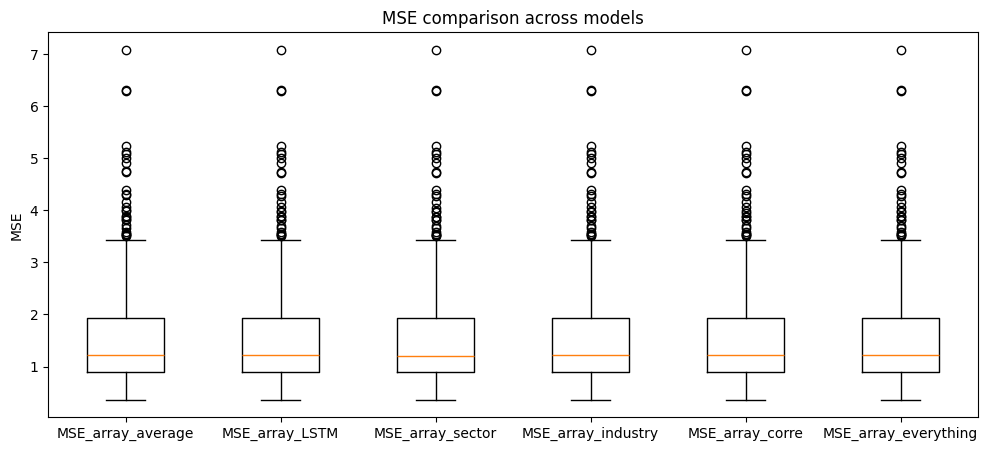

In [44]:
print_box_plots(MSE_dict)